# Predicción de Fallas del Molino Coloidal: Química Latinoamericana
### De mantenimiento reactivo a predictivo: pronóstico a 24 horas, 5 días y 15 días

**Datos:** `Dataset_Molino_QLA_Realista.zip` (1 año, 1 lectura por minuto) y `Bitacora_Mantenimiento_QLA.csv`

# 1. Introducción

## 1.1 De detectar a anticipar

Los notebooks anteriores **identifican** una falla cuando ya está ocurriendo. Eso permite reaccionar rápido, pero la máquina igual falla: se detiene la producción, se pierde material y la reparación se hace con urgencia.

El objetivo ahora es **anticipar** la falla con suficiente tiempo para planificar la intervención:

| Horizonte | Pregunta | Uso en planta |
|---|---|---|
| **24 horas** | ¿Fallará mañana? | Ajustar la operación del día, tener al técnico disponible |
| **5 días** (cubre 3–5 días) | ¿Fallará esta semana? | Programar la intervención antes del fin de semana, pedir repuestos |
| **15 días** | ¿Fallará antes de la próxima mantención mensual? | Agregar la tarea a la mantención mensual o adelantarla |

## 1.2 Por qué es posible anticipar

Las fallas del molino no aparecen de golpe: son el final de un **proceso de degradación** que deja huellas en los sensores durante días.

| Falla | Qué se degrada | Señal previa |
|---|---|---|
| Sobrecarga por asfalto frío | La caldera pierde potencia; el frío invernal la agrava | Baja la temperatura del betún, sube la corriente del motor |
| Filtro obstruido | El filtro acumula sólidos con cada litro | Sube la presión diferencial |
| Radar sucio | Costra de asfalto en la antena | El eco del radar se debilita |
| Cortocircuito del caudalímetro | Humedad en el transmisor (el lavado diario aporta) | Corriente de fuga en el lazo 4–20 mA |
| Falla de la Pt100 | Borneras corroídas | Caídas de voltaje de alimentación |
| Ensuciamiento del intercambiador | Depósitos con cada lote plastomérico | Sube la presión del intercambiador |
| Desgaste de rodamientos | Horas de marcha | Sube la vibración |

## 1.3 Estrategia

Según la cantidad de eventos disponibles en el año, se usan dos enfoques:

* **Fallas frecuentes** (sobrecarga, filtro, radar; 12 a 19 eventos): **machine learning supervisado**. Se comparan tres modelos:
  * **LightGBM** con variables de tendencia.
  * **Random Forest** con las mismas variables.
  * **LSTM**, una red recurrente que lee directamente la secuencia de las últimas 48 horas.
* **Fallas raras** (cortocircuito, Pt100, intercambiador, rodamientos; 2 a 5 eventos): no hay ejemplos suficientes para entrenar un modelo confiable. Se usa un **pronóstico por tendencia**: se ajusta una recta a la señal de degradación de los últimos días y se calcula cuándo cruzará el límite físico de falla.

Al final se descarga el mejor modelo y se muestra un **semáforo de riesgo** por equipo y horizonte, listo para el dashboard.

# 2. Carga de datos

## 2.1 Librerías

In [1]:
import os
import time
import zipfile
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2

import lightgbm as lgb
from lightgbm import LGBMClassifier
import sklearn
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import average_precision_score, roc_auc_score, precision_recall_curve

import warnings
warnings.filterwarnings("ignore")
SEED = 42
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 30)
print("TensorFlow:", tf.__version__, "| scikit-learn:", sklearn.__version__, "| LightGBM:", lgb.__version__)

I0000 00:00:1790888650.125303     385 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1790888650.262419     385 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1790888651.619900     385 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow: 2.21.0 | scikit-learn: 1.8.0 | LightGBM: 4.7.0


## 2.2 Dataset y bitácora de mantenimiento

Se necesitan dos archivos. La bitácora es clave: dice cuándo se limpió el filtro, se reparó la caldera o se cambió un rodamiento, y por lo tanto **desde cuándo se está acumulando el desgaste**.

In [2]:
RUTA = "Dataset_Molino_QLA_Realista.zip"
RUTA_BIT = "Bitacora_Mantenimiento_QLA.csv"

faltan = [r for r in (RUTA, RUTA_BIT) if not os.path.exists(r)]
if faltan:
    try:
        from google.colab import files
        print("Sube los archivos:", ", ".join(faltan))
        files.upload()
    except ImportError:
        raise FileNotFoundError(f"No se encontraron: {faltan}")

TARGET = "LABEL_Estado_Planta"
df = pd.read_csv(RUTA, parse_dates=["timestamp"])
bit = pd.read_csv(RUTA_BIT, parse_dates=["timestamp"])
print(f"Dataset: {len(df):,} minutos, de {df['timestamp'].min():%d-%m-%Y} a {df['timestamp'].max():%d-%m-%Y}".replace(",", "."))
print(f"Bitácora: {len(bit)} intervenciones")
bit.groupby(["equipo", "tipo"]).size().unstack(fill_value=0)

Dataset: 525.600 minutos. de 01-01-2026 a 31-12-2026
Bitácora: 60 intervenciones


tipo,Correctiva,Preventiva mensual
equipo,,
E-301 intercambiador de calor,6,0
F-101 filtro de línea,13,0
FT-201 caudalímetro solución,5,0
MC-01 rodamientos del molino,2,0
Planta completa,0,12
TK-101 caldera / calefactor de betún,6,0
TK-101 radar de nivel,12,0
TT-101 Pt100 betún,4,0


## 2.3 Eventos de falla

Un **evento** es el inicio de una falla después de al menos 24 horas sin ella. Varios episodios cortos seguidos (por ejemplo, sobrecargas en dos lotes del mismo día) cuentan como un solo evento: lo que interesa anticipar es el primero.

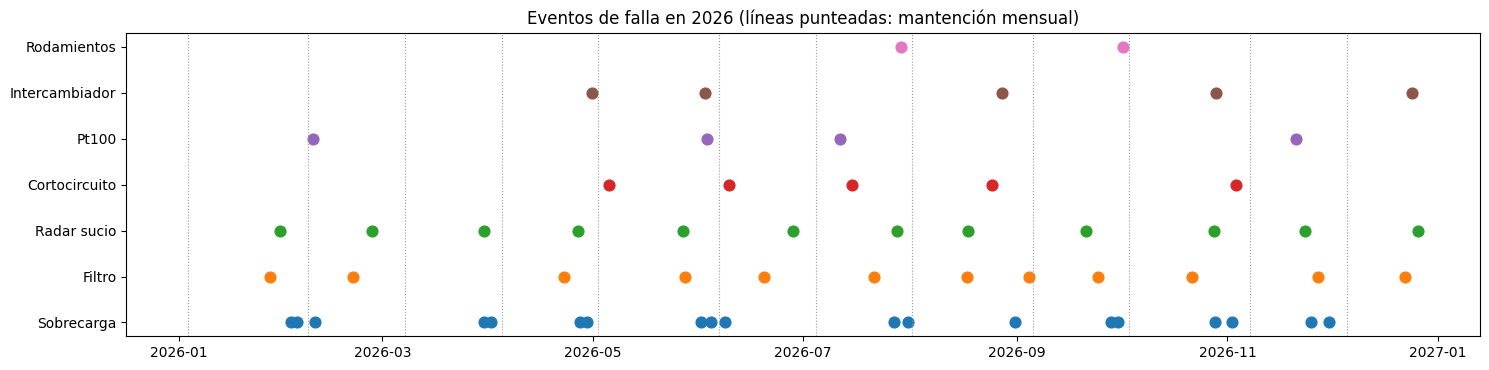

,eventos en el año
Sobrecarga,19
Filtro,12
Radar sucio,12
Cortocircuito,5
Pt100,4
Intercambiador,5
Rodamientos,2


In [3]:
FALLAS = sorted(f for f in df[TARGET].unique() if f != "Normal")
CORTO = {"Sobrecarga_Motor_Por_Asfalto_Frio": "Sobrecarga", "Filtro_Obstruido": "Filtro",
         "Advertencia_Radar_Sucio_Betun": "Radar sucio", "Cortocircuito_Transmisor_Caudal_Sol": "Cortocircuito",
         "Falla_Electrica_PT100_Betun": "Pt100", "Ensuciamiento_Intercambiador": "Intercambiador",
         "Desgaste_Rodamientos_Molino": "Rodamientos"}

def inicios_eventos(falla):
    t = df.loc[df[TARGET] == falla, "timestamp"]
    nuevo = t.diff().isna() | (t.diff() > pd.Timedelta(hours=24))
    return np.sort(t[nuevo].values)

EVENTOS = {f: inicios_eventos(f) for f in FALLAS}

fig, ax = plt.subplots(figsize=(15, 3.8))
for i, f in enumerate(CORTO):
    ax.scatter(EVENTOS[f], [i] * len(EVENTOS[f]), s=60)
ax.set_yticks(range(len(CORTO))); ax.set_yticklabels(CORTO.values())
for m in bit.loc[bit["tipo"] != "Correctiva", "timestamp"]:
    ax.axvline(m, color="#999", lw=0.8, ls=":")
ax.set_title("Eventos de falla en 2026 (líneas punteadas: mantención mensual)")
plt.tight_layout(); plt.show()

pd.Series({CORTO[f]: len(EVENTOS[f]) for f in CORTO}, name="eventos en el año").to_frame()

La mantención mensual reinicia buena parte del desgaste. Aun así, varias fallas ocurren **entre mantenciones**: el filtro se obstruye antes de fin de mes en los meses de mucha producción, y la caldera pierde potencia en invierno. Esas son las fallas que un sistema predictivo puede evitar.

## 2.4 Enfoque por falla

In [4]:
FALLAS_ML = ["Sobrecarga_Motor_Por_Asfalto_Frio", "Filtro_Obstruido", "Advertencia_Radar_Sucio_Betun"]
FALLAS_TENDENCIA = ["Cortocircuito_Transmisor_Caudal_Sol", "Falla_Electrica_PT100_Betun",
                    "Ensuciamiento_Intercambiador", "Desgaste_Rodamientos_Molino"]
HORIZONTES = {"24 h": 24, "5 días": 120, "15 días": 360}
print("Machine learning     :", [CORTO[f] for f in FALLAS_ML])
print("Pronóstico tendencia :", [CORTO[f] for f in FALLAS_TENDENCIA])

Machine learning     : ['Sobrecarga', 'Filtro', 'Radar sucio']
Pronóstico tendencia : ['Cortocircuito', 'Pt100', 'Intercambiador', 'Rodamientos']


# 3. Construcción de variables

La predicción se hace **cada hora**. Para cada hora se construyen variables que resumen el estado del equipo y su evolución reciente.

## 3.1 Desviación respecto de lo normal en el mismo modo de operación

Una corriente de 117 A es normal fabricando plastomérico pero alta en convencional, y un motor detenido tiene corriente cero. Para comparar peras con peras, cada sensor se expresa como **desviación respecto de su valor típico en el mismo modo de operación** (estado × tipo de asfalto). Los valores típicos se calculan solo con datos normales del periodo de entrenamiento.

Algunas señales solo tienen sentido con la planta produciendo (corriente, vibración, presión del filtro); en los demás minutos se dejan vacías y se arrastra el último valor conocido.

In [5]:
FIN_ENTRENAMIENTO = pd.Timestamp("2026-07-01")
FIN_VALIDACION = pd.Timestamp("2026-09-01")

SENSORES = ["TEM_son_betum_in", "AMP_eco_betum_dep", "VOLT_son_betum_in", "AMP_cau_solucion_in",
            "AMP_vfd_motor_molino", "TOR_vfd_motor_molino", "VIB_vel_motor_molino",
            "PRE_dif_filtro_bar", "PRE_intercambiador_bar", "CAU_bomba_lpm"]
SOLO_PRODUCCION = ["AMP_vfd_motor_molino", "TOR_vfd_motor_molino", "VIB_vel_motor_molino",
                   "PRE_dif_filtro_bar", "PRE_intercambiador_bar", "CAU_bomba_lpm"]

modo = df["ESTADO_operacion"] + "|" + df["TIPO_asfalto"]
ref = (df[TARGET] == "Normal") & (df["timestamp"] < FIN_ENTRENAMIENTO)
REFERENCIAS = df.loc[ref, SENSORES].groupby(modo[ref]).median()

res = (df[SENSORES] - REFERENCIAS.reindex(modo).values).astype("float32")
produccion = (df["ESTADO_operacion"] == "Produccion").values
res.loc[~produccion, SOLO_PRODUCCION] = np.nan
res.loc[~(produccion & (df["TIPO_asfalto"] == "Plastomerico")).values, "PRE_intercambiador_bar"] = np.nan
res.columns = [f"dev_{c}" for c in SENSORES]
REFERENCIAS.round(2)

,TEM_son_betum_in,AMP_eco_betum_dep,VOLT_son_betum_in,AMP_cau_solucion_in,AMP_vfd_motor_molino,TOR_vfd_motor_molino,VIB_vel_motor_molino,PRE_dif_filtro_bar,PRE_intercambiador_bar,CAU_bomba_lpm
Detenida|Convencional,134.73,53.98,23.78,4.21,0.00,0.00,0.10,0.01,0.00,0.00
Detenida|Ninguno,136.24,56.01,23.77,4.19,0.00,0.00,0.10,0.01,0.00,0.00
Detenida|Plastomerico,179.19,56.90,23.59,4.24,0.00,0.00,0.10,0.01,0.00,0.00
Espera|Convencional,134.27,53.99,23.78,4.20,0.00,0.00,0.10,0.01,0.00,0.00
Espera|Plastomerico,182.64,57.00,23.72,4.22,0.00,0.00,0.10,0.01,0.00,0.00
Limpieza|Convencional,134.80,54.26,23.75,4.22,58.50,39.69,2.49,0.50,0.00,260.27
Limpieza|Plastomerico,183.93,56.66,23.56,4.26,58.93,39.80,2.65,0.65,0.00,259.72
Mantenimiento|Ninguno,128.69,55.87,23.13,5.17,0.00,0.00,0.10,0.01,0.00,0.00
Preparacion|Convencional,134.13,53.81,23.79,4.19,0.00,0.00,0.10,0.01,0.00,0.00
Preparacion|Plastomerico,179.28,56.94,23.65,4.20,0.00,0.00,0.10,0.01,0.00,0.00


## 3.2 Resumen por hora

In [6]:
hora = df["timestamp"].dt.floor("h")
H = res.groupby(hora).mean()
H["dev_VOLT_min"] = res["dev_VOLT_son_betum_in"].groupby(hora).min()       # caídas de voltaje de la Pt100
H["picos_TEM"] = (res["dev_TEM_son_betum_in"] < -5).groupby(hora).sum()      # lecturas erráticas de temperatura
H["EST_radar"] = df["EST_niv_betum_dep"].groupby(hora).mean()
H["min_produccion"] = pd.Series(produccion).groupby(hora.values).sum().values
H["min_plastomerico"] = pd.Series(produccion & (df["TIPO_asfalto"] == "Plastomerico").values).groupby(hora.values).sum().values
H["litros"] = (df["CAU_bomba_lpm"] * produccion).groupby(hora).sum()
BASE = [c for c in H.columns if c not in ("min_produccion", "min_plastomerico", "litros")]
H[BASE] = H[BASE].ffill().fillna(0)
print(f"{len(H):,} horas x {H.shape[1]} columnas".replace(",", "."))
H.head()

8.760 horas x 16 columnas


,dev_TEM_son_betum_in,dev_AMP_eco_betum_dep,dev_VOLT_son_betum_in,dev_AMP_cau_solucion_in,dev_AMP_vfd_motor_molino,dev_TOR_vfd_motor_molino,dev_VIB_vel_motor_molino,dev_PRE_dif_filtro_bar,dev_PRE_intercambiador_bar,dev_CAU_bomba_lpm,dev_VOLT_min,picos_TEM,EST_radar,min_produccion,min_plastomerico,litros
timestamp,,,,,,,,,,,,,,,,
2026-01-01 00:00:00,53.951000,6.364433,0.23,-0.192533,0.0,0.0,0.0,0.0,0.0,0.0,0.23,0,0.0,0,0,0.0
2026-01-01 01:00:00,53.442001,5.609533,0.23,-0.183567,0.0,0.0,0.0,0.0,0.0,0.0,0.23,0,0.0,0,0,0.0
2026-01-01 02:00:00,53.578835,6.526300,0.23,-0.168033,0.0,0.0,0.0,0.0,0.0,0.0,0.23,0,0.0,0,0,0.0
2026-01-01 03:00:00,53.521835,5.921783,0.23,-0.173050,0.0,0.0,0.0,0.0,0.0,0.0,0.23,0,0.0,0,0,0.0
2026-01-01 04:00:00,54.046833,6.417483,0.23,-0.198167,0.0,0.0,0.0,0.0,0.0,0.0,0.23,0,0.0,0,0,0.0


## 3.3 Desgaste acumulado desde la última intervención

Con la bitácora se calcula, para cada equipo, cuánto tiempo y cuánto uso lleva desde que se limpió, reparó o cambió por última vez. Se considera una intervención:

* Cualquier **reparación correctiva** del equipo.
* La **mantención mensual**, cuando su descripción indica que se atendió ese equipo (el filtro, el intercambiador y la antena del radar se limpian siempre; la caldera, las borneras y los rodamientos solo a veces).

In [7]:
INTERVENCIONES = {   # equipo: (texto en la columna equipo para correctivas, texto en la mantención mensual)
    "filtro": ("filtro", "limpieza de filtro"),
    "radar": ("radar", "antena del radar"),
    "caldera": ("caldera", "mantención de caldera"),
    "intercambiador": ("intercambiador", "intercambiador"),
    "caudalimetro": ("caudalímetro", "transmisor de caudal"),
    "pt100": ("pt100", "borneras"),
    "rodamientos": ("rodamientos", "cambio preventivo de rodamientos"),
}

def fechas_intervencion(eq):
    txt_equipo, txt_mensual = INTERVENCIONES[eq]
    corr = bit.loc[(bit["tipo"] == "Correctiva") & bit["equipo"].str.lower().str.contains(txt_equipo), "timestamp"]
    mens = bit.loc[(bit["tipo"] != "Correctiva") & bit["descripcion"].str.lower().str.contains(txt_mensual), "timestamp"]
    return np.sort(pd.concat([corr, mens]).values)

t_pred = H.index + pd.Timedelta(hours=1)          # la predicción se emite al cerrar cada hora
acum = H[["litros", "min_plastomerico", "min_produccion"]].cumsum()

def desde_ultima(eq):
    f = fechas_intervencion(eq)
    idx = np.searchsorted(f, t_pred.values, side="right") - 1
    ultima = np.where(idx >= 0, f[np.maximum(idx, 0)], np.datetime64(df["timestamp"].min()))
    horas = (t_pred.values - ultima) / np.timedelta64(1, "h")
    pos = np.searchsorted(H.index.values, ultima)
    base = acum.iloc[np.clip(pos - 1, 0, len(acum) - 1)].values * (pos > 0)[:, None]
    return horas, acum.values - base

for eq in INTERVENCIONES:
    horas, uso = desde_ultima(eq)
    H[f"horas_desde_{eq}"] = horas
H["litros_desde_filtro"] = desde_ultima("filtro")[1][:, 0] / 1000
H["min_plasto_desde_intercambiador"] = desde_ultima("intercambiador")[1][:, 1]
H["horas_marcha_desde_rodamientos"] = desde_ultima("rodamientos")[1][:, 2] / 60
H[[c for c in H.columns if "desde" in c]].describe().T[["mean", "max"]].round(1)

,mean,max
horas_desde_filtro,200.0,603.0
horas_desde_radar,225.8,647.0
horas_desde_caldera,373.0,1050.0
horas_desde_intercambiador,311.0,839.0
horas_desde_caudalimetro,405.7,965.9
horas_desde_pt100,387.9,1219.0
horas_desde_rodamientos,942.2,2191.0
litros_desde_filtro,139.5,422.9
min_plasto_desde_intercambiador,216.6,845.0
horas_marcha_desde_rodamientos,62.6,145.7


## 3.4 Tendencias y contexto

Para cada señal se calculan:

* **Promedios móviles** de las últimas 24 horas, 3 días y 7 días.
* **Cambios**: cuánto subió o bajó el promedio de 24 horas respecto de hace 3 y 7 días. Son la "pendiente" de la degradación.

Además se agrega contexto de calendario: estación del año (seno y coseno del día del año), día de la semana y hora. Las sobrecargas, por ejemplo, son más probables en invierno y los lunes en la mañana.

In [8]:
TAB = pd.DataFrame(index=H.index)
for c in BASE:
    m24 = H[c].rolling(24, min_periods=1).mean()
    TAB[f"{c}_m24"] = m24
    TAB[f"{c}_m72"] = H[c].rolling(72, min_periods=1).mean()
    TAB[f"{c}_m168"] = H[c].rolling(168, min_periods=1).mean()
    TAB[f"{c}_d72"] = m24 - m24.shift(72)
    TAB[f"{c}_d168"] = m24 - m24.shift(168)
for c in H.columns:
    if "desde" in c:
        TAB[c] = H[c]
TAB["litros_24h"] = H["litros"].rolling(24, min_periods=1).sum() / 1000
doy = t_pred.dayofyear.values
TAB["estacion_sin"], TAB["estacion_cos"] = np.sin(2 * np.pi * doy / 365), np.cos(2 * np.pi * doy / 365)
TAB["dia_semana"], TAB["hora"] = t_pred.dayofweek.values, t_pred.hour.values
TAB = TAB.fillna(0).astype("float32")
FEATURES_TAB = list(TAB.columns)
print(f"Variables tabulares: {len(FEATURES_TAB)}")

Variables tabulares: 80


## 3.5 Objetivos: ¿habrá falla en las próximas H horas?

Para cada falla y horizonte, el objetivo de la hora *t* vale 1 si un evento de esa falla comienza entre *t* y *t + H*.

Las horas en que la falla está ocurriendo (o terminó hace menos de 24 horas) se excluyen de la evaluación de esa falla: anticipar algo que ya está pasando no tiene valor.

In [9]:
def objetivo(falla, h):
    ini = EVENTOS[falla]
    idx = np.searchsorted(ini, t_pred.values, side="right")
    ok = idx < len(ini)
    y = np.zeros(len(t_pred), dtype=int)
    y[ok] = (ini[idx[ok]] - t_pred.values[ok]) <= np.timedelta64(h, "h")
    return y

ACTIVA = {f: (df[TARGET] == f).groupby(hora).any().reindex(H.index, fill_value=False).astype(float).rolling(24, min_periods=1).max().astype(bool).values
          for f in FALLAS}
Y = {(f, hz): objetivo(f, h) for f in FALLAS for hz, h in HORIZONTES.items()}

# conjuntos (todas las filas deben tener el horizonte más largo completo dentro de los datos)
fin_datos = df["timestamp"].max() - pd.Timedelta(hours=max(HORIZONTES.values()))
en_tr = np.asarray(t_pred < FIN_ENTRENAMIENTO)
en_va = np.asarray((t_pred >= FIN_ENTRENAMIENTO) & (t_pred < FIN_VALIDACION))
en_te = np.asarray((t_pred >= FIN_VALIDACION) & (t_pred <= fin_datos))
en_tr[:168] = False                                                     # primera semana: tendencias incompletas

resumen = pd.DataFrame({f"{CORTO[f]} {hz}": [Y[f, hz][m].mean() * 100 for m in (en_tr, en_va, en_te)]
                        for f in FALLAS_ML for hz in HORIZONTES}, index=["% positivos train", "% positivos val", "% positivos test"]).T
print(f"Horas -> train {en_tr.sum()}, validación {en_va.sum()}, prueba {en_te.sum()}")
print("Eventos en prueba:", {CORTO[f]: int(((EVENTOS[f] >= np.datetime64(FIN_VALIDACION)) & (EVENTOS[f] <= np.datetime64(df['timestamp'].max()))).sum()) for f in FALLAS})
resumen.round(1)

Horas -> train 4175, validación 1488, prueba 2568
Eventos en prueba: {'Radar sucio': 4, 'Cortocircuito': 1, 'Rodamientos': 1, 'Intercambiador': 2, 'Pt100': 1, 'Filtro': 5, 'Sobrecarga': 6}


,% positivos train,% positivos val,% positivos test
Sobrecarga 24 h,5.7,4.8,5.6
Sobrecarga 5 días,21.8,22.6,25.2
Sobrecarga 15 días,45.0,54.8,53.3
Filtro 24 h,2.9,3.2,3.7
Filtro 5 días,14.4,18.7,17.2
Filtro 15 días,43.1,67.1,54.2
Radar sucio 24 h,3.4,3.2,2.8
Radar sucio 5 días,17.2,16.1,14.0
Radar sucio 15 días,51.7,48.4,47.3


Entrenamiento: enero a junio. Validación: julio y agosto (para elegir hiperparámetros y el umbral de alerta). Prueba: septiembre a mediados de diciembre.

## 3.6 Secuencias para la LSTM

La LSTM no recibe las tendencias ya calculadas: recibe la **secuencia de las últimas 48 horas** de las señales base y el desgaste acumulado, y aprende por sí misma qué patrones temporales anticipan la falla.

In [10]:
SEQ = 48
COLS_SEQ = BASE + [c for c in H.columns if "desde" in c] + ["min_produccion"]
sc_seq = StandardScaler().fit(H.loc[en_tr, COLS_SEQ])
Hs = sc_seq.transform(H[COLS_SEQ]).astype("float32")
idx_validos = np.arange(SEQ - 1, len(H))
SEQS = np.lib.stride_tricks.sliding_window_view(Hs, (SEQ, Hs.shape[1]))[:, 0]      # (n - SEQ + 1, SEQ, columnas)

def secuencias(mascara):
    i = np.where(mascara)[0]
    i = i[i >= SEQ - 1]
    return SEQS[i - (SEQ - 1)], i

print("Forma de una secuencia:", SEQS.shape[1:])

Forma de una secuencia: (48, 24)


# 4. Modelos y regularización

## 4.1 Funciones de evaluación

Se miden dos cosas:

1. **PR-AUC por hora:** qué tan bien ordena el modelo las horas de riesgo, sin depender del umbral. Es la métrica adecuada cuando los positivos son pocos.
2. **Evaluación por evento**, con el umbral elegido en validación:
   * **% de eventos anticipados:** fallas para las que hubo al menos una alerta en la ventana previa del horizonte.
   * **Anticipación media:** horas entre la primera alerta y el inicio de la falla.
   * **Falsas alertas por mes:** episodios de alerta después de los cuales no ocurrió la falla dentro del horizonte.

In [11]:
def umbral_optimo(y, p):
    if y.sum() == 0:
        return 0.5
    pr, rc, th = precision_recall_curve(y, p)
    f1 = 2 * pr * rc / np.maximum(pr + rc, 1e-9)
    return float(th[np.argmax(f1[:-1])]) if len(th) else 0.5

def evaluar_eventos(prob, umbral, tiempos, inicios, h, excluir):
    tiempos = np.asarray(tiempos)
    alerta = (prob >= umbral) & ~excluir
    t0, t1 = tiempos.min(), tiempos.max()
    ev = inicios[(inicios > t0 + np.timedelta64(h, "h")) & (inicios <= t1 + np.timedelta64(h, "h"))]
    leads = []
    for s in ev:
        v = (tiempos >= s - np.timedelta64(h, "h")) & (tiempos < s) & alerta
        leads.append((s - tiempos[v].min()) / np.timedelta64(1, "h") if v.any() else np.nan)
    onset = alerta & ~np.r_[False, alerta[:-1]]
    falsas = 0
    for t in tiempos[onset]:
        k = np.searchsorted(inicios, t, side="right")
        if not (k < len(inicios) and inicios[k] - t <= np.timedelta64(h, "h")):
            falsas += 1
    meses = (t1 - t0) / np.timedelta64(30, "D")
    leads = np.array(leads)
    return {"eventos": len(ev), "anticipados_%": 100 * np.mean(~np.isnan(leads)) if len(ev) else np.nan,
            "anticipacion_media_h": np.nanmean(leads) if (~np.isnan(leads)).any() else np.nan,
            "anticipados_3dias_%": 100 * np.mean(leads >= 72) if len(ev) else np.nan,
            "falsas_alertas_mes": falsas / meses}

def pr_auc(y, p):
    return average_precision_score(y, p) if y.sum() > 0 else np.nan

## 4.2 LightGBM

Un modelo por falla y horizonte (3 × 3 = 9 modelos). Se comparan tres niveles de regularización:

| Nivel | Hojas por árbol | Mínimo de horas por hoja | L1 / L2 |
|---|---|---|---|
| Flexible | 63 | 5 | 0 / 0 |
| Moderado | 15 | 30 | 0 / 1 |
| Fuerte | 7 | 80 | 1 / 10 |

Todos usan early stopping sobre validación y compensan el desbalance con `scale_pos_weight`.

In [12]:
NIVELES_LGBM = {"flexible": dict(num_leaves=63, min_child_samples=5, reg_alpha=0.0, reg_lambda=0.0),
                "moderado": dict(num_leaves=15, min_child_samples=30, reg_alpha=0.0, reg_lambda=1.0),
                "fuerte":   dict(num_leaves=7, min_child_samples=80, reg_alpha=1.0, reg_lambda=10.0)}
X_tab = TAB.values

def lgbm(nivel, y, n_estimators=2000):
    pos = max(y.sum(), 1)
    return LGBMClassifier(n_estimators=n_estimators, learning_rate=0.03, subsample=0.8, subsample_freq=1,
                          colsample_bytree=0.7, scale_pos_weight=(len(y) - pos) / pos, random_state=SEED,
                          verbose=-1, **NIVELES_LGBM[nivel])

filas, cfg_lgbm, prob_val = [], {}, {}
for f in FALLAS_ML:
    for hz in HORIZONTES:
        y = Y[f, hz]
        mejor = (-1, None)
        for nivel in NIVELES_LGBM:
            m = lgbm(nivel, y[en_tr])
            m.fit(X_tab[en_tr], y[en_tr], eval_set=[(X_tab[en_va], y[en_va])], callbacks=[lgb.early_stopping(100, verbose=False)])
            p = m.predict_proba(X_tab[en_va])[:, 1]
            ap = pr_auc(y[en_va & ~ACTIVA[f]], p[~ACTIVA[f][en_va]])
            filas.append({"falla": CORTO[f], "horizonte": hz, "nivel": nivel, "arboles": m.best_iteration_, "PR_AUC_val": ap})
            if (ap if not np.isnan(ap) else 0) > mejor[0]:
                mejor = (ap if not np.isnan(ap) else 0, nivel, m.best_iteration_, p)
        cfg_lgbm[f, hz] = {"nivel": mejor[1], "arboles": max(int(mejor[2] or 50), 20)}
        prob_val["LightGBM", f, hz] = mejor[3]
tabla_lgbm = pd.DataFrame(filas)
tabla_lgbm.pivot_table(index=["falla", "horizonte"], columns="nivel", values="PR_AUC_val").round(3)

nivel                  flexible  fuerte  moderado
falla       horizonte                            
Filtro      15 días       0.761   0.829     0.806
            24 h          0.598   0.425     0.592
            5 días        0.689   0.881     0.687
Radar sucio 15 días       0.900   0.875     0.895
            24 h          0.831   0.969     0.914
            5 días        0.884   0.953     0.970
Sobrecarga  15 días       0.492   0.487     0.471
            24 h          0.231   0.497     0.490
            5 días        0.493   0.471     0.432

## 4.3 Random Forest

Un bosque **multisalida** por horizonte: un solo modelo predice a la vez las tres fallas. Regularización por profundidad y tamaño mínimo de hoja.

In [13]:
NIVELES_RF = {"flexible": dict(max_depth=None, min_samples_leaf=1), "moderado": dict(max_depth=12, min_samples_leaf=20),
              "fuerte": dict(max_depth=6, min_samples_leaf=60)}

def rf(nivel):
    return RandomForestClassifier(n_estimators=300, max_features="sqrt", class_weight="balanced_subsample",
                                  n_jobs=-1, random_state=SEED, **NIVELES_RF[nivel])

def prob_multi(modelo, X):
    return np.column_stack([p[:, 1] for p in modelo.predict_proba(X)])

filas, cfg_rf = [], {}
for hz in HORIZONTES:
    Ym = np.column_stack([Y[f, hz] for f in FALLAS_ML])
    mejor = (-1, None, None)
    for nivel in NIVELES_RF:
        m = rf(nivel).fit(X_tab[en_tr], Ym[en_tr])
        P = prob_multi(m, X_tab[en_va])
        aps = [pr_auc(Ym[en_va, j][~ACTIVA[f][en_va]], P[~ACTIVA[f][en_va], j]) for j, f in enumerate(FALLAS_ML)]
        filas.append({"horizonte": hz, "nivel": nivel, **{CORTO[f]: a for f, a in zip(FALLAS_ML, aps)}, "PR_AUC_medio": np.nanmean(aps)})
        if np.nanmean(aps) > mejor[0]:
            mejor = (np.nanmean(aps), nivel, P)
    cfg_rf[hz] = mejor[1]
    for j, f in enumerate(FALLAS_ML):
        prob_val["Random Forest", f, hz] = mejor[2][:, j]
pd.DataFrame(filas).set_index(["horizonte", "nivel"]).round(3)

Sobrecarga  Filtro  Radar sucio  PR_AUC_medio
horizonte nivel                                                  
24 h      flexible       0.187   0.512        0.927         0.542
          moderado       0.173   0.577        0.870         0.540
          fuerte         0.192   0.601        0.854         0.549
5 días    flexible       0.199   0.779        0.954         0.644
          moderado       0.193   0.847        0.967         0.669
          fuerte         0.174   0.851        0.967         0.664
15 días   flexible       0.435   0.844        0.913         0.730
          moderado       0.428   0.825        0.897         0.717
          fuerte         0.431   0.839        0.864         0.711

## 4.4 LSTM

Una red por horizonte con tres salidas sigmoide (una por falla). Se comparan dos variantes:

* **base:** 24 unidades LSTM, sin regularización salvo EarlyStopping.
* **regularizada:** L2 sobre los pesos, Dropout sobre la entrada de la capa recurrente y sobre la capa densa.

In [14]:
def crear_lstm(variante, n_cols, n_salidas=len(FALLAS_ML)):
    reg = l2(1e-3) if variante == "regularizada" else None
    m = Sequential([Input(shape=(SEQ, n_cols)),
                    LSTM(24, kernel_regularizer=reg, dropout=0.3 if variante == "regularizada" else 0.0),
                    Dropout(0.3 if variante == "regularizada" else 0.0),
                    Dense(16, activation="relu", kernel_regularizer=reg),
                    Dense(n_salidas, activation="sigmoid")])
    m.compile(optimizer=keras.optimizers.Adam(1e-3), loss="binary_crossentropy")
    return m

Xs_tr, i_tr = secuencias(en_tr)
Xs_va, i_va = secuencias(en_va)
filas, cfg_lstm, hist_lstm = [], {}, {}
for hz in HORIZONTES:
    Ym = np.column_stack([Y[f, hz] for f in FALLAS_ML]).astype("float32")
    mejor = (-1, None, None, None)
    for variante in ("base", "regularizada"):
        tf.keras.utils.set_random_seed(SEED)
        m = crear_lstm(variante, Xs_tr.shape[2])
        h = m.fit(Xs_tr, Ym[i_tr], validation_data=(Xs_va, Ym[i_va]), epochs=30, batch_size=64, verbose=0,
                  callbacks=[EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True)])
        hist_lstm[hz, variante] = h.history
        P = m.predict(Xs_va, verbose=0)
        aps = [pr_auc(Ym[i_va, j][~ACTIVA[f][i_va]], P[~ACTIVA[f][i_va], j]) for j, f in enumerate(FALLAS_ML)]
        ep = int(np.argmin(h.history["val_loss"])) + 1
        filas.append({"horizonte": hz, "variante": variante, "epocas": ep, **{CORTO[f]: a for f, a in zip(FALLAS_ML, aps)},
                      "PR_AUC_medio": np.nanmean(aps)})
        if np.nanmean(aps) > mejor[0]:
            mejor = (np.nanmean(aps), variante, ep, P)
    cfg_lstm[hz] = {"variante": mejor[1], "epocas": max(mejor[2], 3)}
    for j, f in enumerate(FALLAS_ML):
        p = np.full(en_va.sum(), np.nan, dtype="float32")
        p[np.isin(np.where(en_va)[0], i_va)] = mejor[3][:, j]
        prob_val["LSTM", f, hz] = np.nan_to_num(p, nan=0.0)
pd.DataFrame(filas).set_index(["horizonte", "variante"]).round(3)

epocas  Sobrecarga  Filtro  Radar sucio  PR_AUC_medio
horizonte variante                                                           
24 h      base               3       0.095   0.410        0.157         0.220
          regularizada      11       0.114   0.425        0.224         0.254
5 días    base               3       0.261   0.833        0.990         0.695
          regularizada      17       0.433   0.986        0.912         0.777
15 días   base               1       0.885   0.751        0.795         0.810
          regularizada       1       0.817   0.790        0.634         0.747

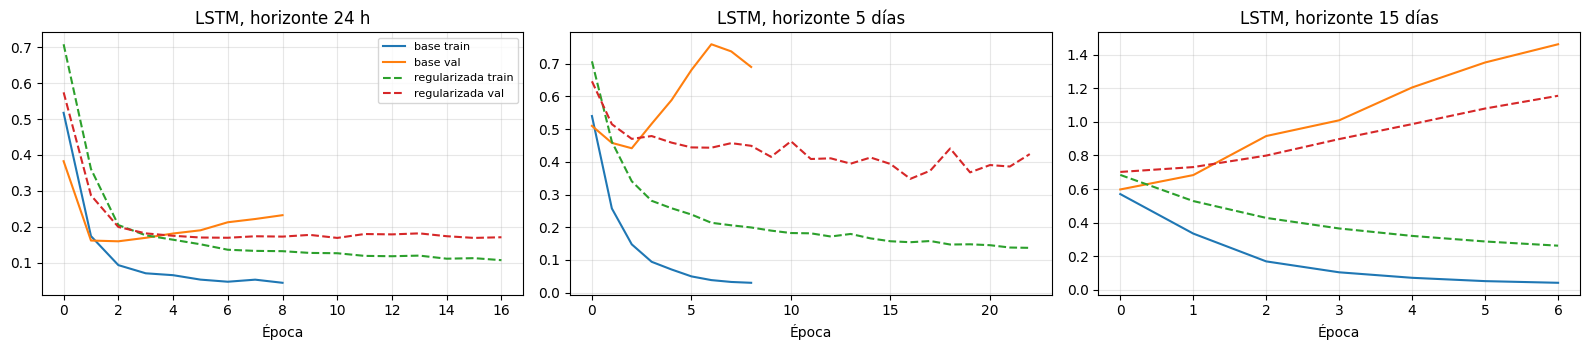

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 3.6))
for ax, hz in zip(axes, HORIZONTES):
    for variante, estilo in (("base", "-"), ("regularizada", "--")):
        h = hist_lstm[hz, variante]
        ax.plot(h["loss"], estilo, label=f"{variante} train"); ax.plot(h["val_loss"], estilo, label=f"{variante} val")
    ax.set_title(f"LSTM, horizonte {hz}"); ax.set_xlabel("Época"); ax.grid(alpha=0.3)
axes[0].legend(fontsize=8); plt.tight_layout(); plt.show()

# 5. Reentrenamiento y evaluación en prueba

Cada modelo se reentrena con la configuración elegida usando **entrenamiento + validación** (enero a agosto) y se evalúa en el periodo de prueba (septiembre a diciembre). El umbral de alerta se fija en validación, maximizando el F1 por hora.

In [16]:
en_hist = en_tr | en_va
FAMILIAS = ["LightGBM", "Random Forest", "LSTM"]
UMBRALES = {}
for (fam, f, hz), p in prob_val.items():
    y = Y[f, hz][en_va]
    UMBRALES[fam, f, hz] = umbral_optimo(y[~ACTIVA[f][en_va]], p[~ACTIVA[f][en_va]])

FINALES = {"LightGBM": {}, "Random Forest": {}, "LSTM": {}}
prob_test = {}
Xs_hist, i_hist = secuencias(en_hist)
Xs_te, i_te = secuencias(en_te)
for hz in HORIZONTES:
    for f in FALLAS_ML:
        c = cfg_lgbm[f, hz]
        m = lgbm(c["nivel"], Y[f, hz][en_hist], n_estimators=int(c["arboles"] * 1.1)).fit(X_tab[en_hist], Y[f, hz][en_hist])
        FINALES["LightGBM"][f, hz] = m
        prob_test["LightGBM", f, hz] = m.predict_proba(X_tab[en_te])[:, 1]
    Ym = np.column_stack([Y[f, hz] for f in FALLAS_ML])
    m = rf(cfg_rf[hz]).fit(X_tab[en_hist], Ym[en_hist])
    FINALES["Random Forest"][hz] = m
    P = prob_multi(m, X_tab[en_te])
    tf.keras.utils.set_random_seed(SEED)
    ml = crear_lstm(cfg_lstm[hz]["variante"], Xs_hist.shape[2])
    ml.fit(Xs_hist, Ym[i_hist].astype("float32"), epochs=cfg_lstm[hz]["epocas"], batch_size=64, verbose=0)
    FINALES["LSTM"][hz] = ml
    PL = ml.predict(Xs_te, verbose=0)
    for j, f in enumerate(FALLAS_ML):
        prob_test["Random Forest", f, hz] = P[:, j]
        prob_test["LSTM", f, hz] = PL[:, j]

filas = []
tiempos_te = t_pred.values[en_te]
for fam in FAMILIAS:
    for f in FALLAS_ML:
        for hz, h in HORIZONTES.items():
            y, p, ex = Y[f, hz][en_te], prob_test[fam, f, hz], ACTIVA[f][en_te]
            ev = evaluar_eventos(p, UMBRALES[fam, f, hz], tiempos_te, EVENTOS[f], h, ex)
            filas.append({"modelo": fam, "falla": CORTO[f], "horizonte": hz,
                          "PR_AUC_val": pr_auc(Y[f, hz][en_va][~ACTIVA[f][en_va]], prob_val[fam, f, hz][~ACTIVA[f][en_va]]),
                          "PR_AUC_test": pr_auc(y[~ex], p[~ex]), "positivos_test_%": 100 * y[~ex].mean(), **ev})
RESULTADOS = pd.DataFrame(filas)
RESULTADOS.pivot_table(index=["falla", "horizonte"], columns="modelo", values="PR_AUC_test").round(3)

modelo                  LSTM  LightGBM  Random Forest
falla       horizonte                                
Filtro      15 días    0.818     0.863          0.851
            24 h       0.715     0.432          0.555
            5 días     0.598     0.599          0.728
Radar sucio 15 días    0.742     0.878          0.904
            24 h       0.416     0.771          0.818
            5 días     0.387     0.899          0.671
Sobrecarga  15 días    0.827     0.807          0.855
            24 h       0.318     0.564          0.465
            5 días     0.883     0.866          0.875

**Cómo leer el PR-AUC:** un modelo que no sabe nada obtiene un PR-AUC igual al porcentaje de horas positivas (columna `positivos_test_%` dividida por 100). Todo lo que esté por encima de ese valor es capacidad real de anticipación.

## 5.1 Resultados por evento

In [17]:
resumen_fam = RESULTADOS.groupby("modelo")[["PR_AUC_val", "PR_AUC_test", "anticipados_%", "anticipacion_media_h", "falsas_alertas_mes"]].mean()
print("Promedio sobre las 9 combinaciones falla × horizonte")
resumen_fam.round(3)

Promedio sobre las 9 combinaciones falla × horizonte


,PR_AUC_val,PR_AUC_test,anticipados_%,anticipacion_media_h,falsas_alertas_mes
modelo,,,,,
LSTM,0.614,0.634,67.593,157.779,1.184
LightGBM,0.737,0.742,89.815,147.943,1.589
Random Forest,0.649,0.747,94.444,160.369,1.995


In [18]:
tabla_ev = RESULTADOS.set_index(["falla", "horizonte", "modelo"])[["eventos", "anticipados_%", "anticipacion_media_h", "anticipados_3dias_%", "falsas_alertas_mes"]]
tabla_ev.unstack("modelo").round(1)

eventos                        anticipados_%                        anticipacion_media_h                        anticipados_3dias_%                        falsas_alertas_mes  \
modelo                   LSTM LightGBM Random Forest          LSTM LightGBM Random Forest                 LSTM LightGBM Random Forest                LSTM LightGBM Random Forest               LSTM   
falla       horizonte                                                                                                                                                                                 
Filtro      15 días         4        4             4         100.0    100.0         100.0                335.3    359.5         359.5               100.0    100.0         100.0                2.2   
            24 h            4        4             4           0.0     25.0          50.0                  NaN     23.8          19.9                 0.0      0.0           0.0                0.0   
            5 días          3        3             3         100.0    100.0         100.0                 88.1    119.4         119.4                66.7    100.0         100.0                1.1   
Radar sucio 15 días         4        4             4          75.0    100.0         100.0                280.5    346.6         350.8                75.0    100.0         100.0                2.0   
            24 h            3        3             3          33.3    100.0         100.0                 23.6     16.0          17.4                 0.0      0.0           0.0                0.3   
            5 días          3        3             3          33.3    100.0         100.0                119.6    104.4          82.7                33.3    100.0          33.3                1.7   
Sobrecarga  15 días         6        6             6         100.0    100.0         100.0                316.6    234.3         359.5               100.0    100.0         100.0                0.6   
            24 h            6        6             6          66.7    100.0         100.0                 18.0     22.5          22.5                 0.0      0.0           0.0                1.7   
            5 días          6        6             6         100.0     83.3         100.0                 80.6    105.0         111.6                66.7     83.3         100.0                1.1   

                                              
modelo                LightGBM Random Forest  
falla       horizonte                         
Filtro      15 días        2.5           1.1  
            24 h           1.1           0.3  
            5 días         2.0           2.5  
Radar sucio 15 días        2.2           2.8  
            24 h           0.3           0.8  
            5 días         1.1           0.3  
Sobrecarga  15 días        0.6           3.1  
            24 h           2.5           2.5  
            5 días         2.0           4.5

## 5.2 Mejor modelo

Se elige la familia con mayor **PR-AUC promedio en validación**.

Mejor familia según validación: LightGBM


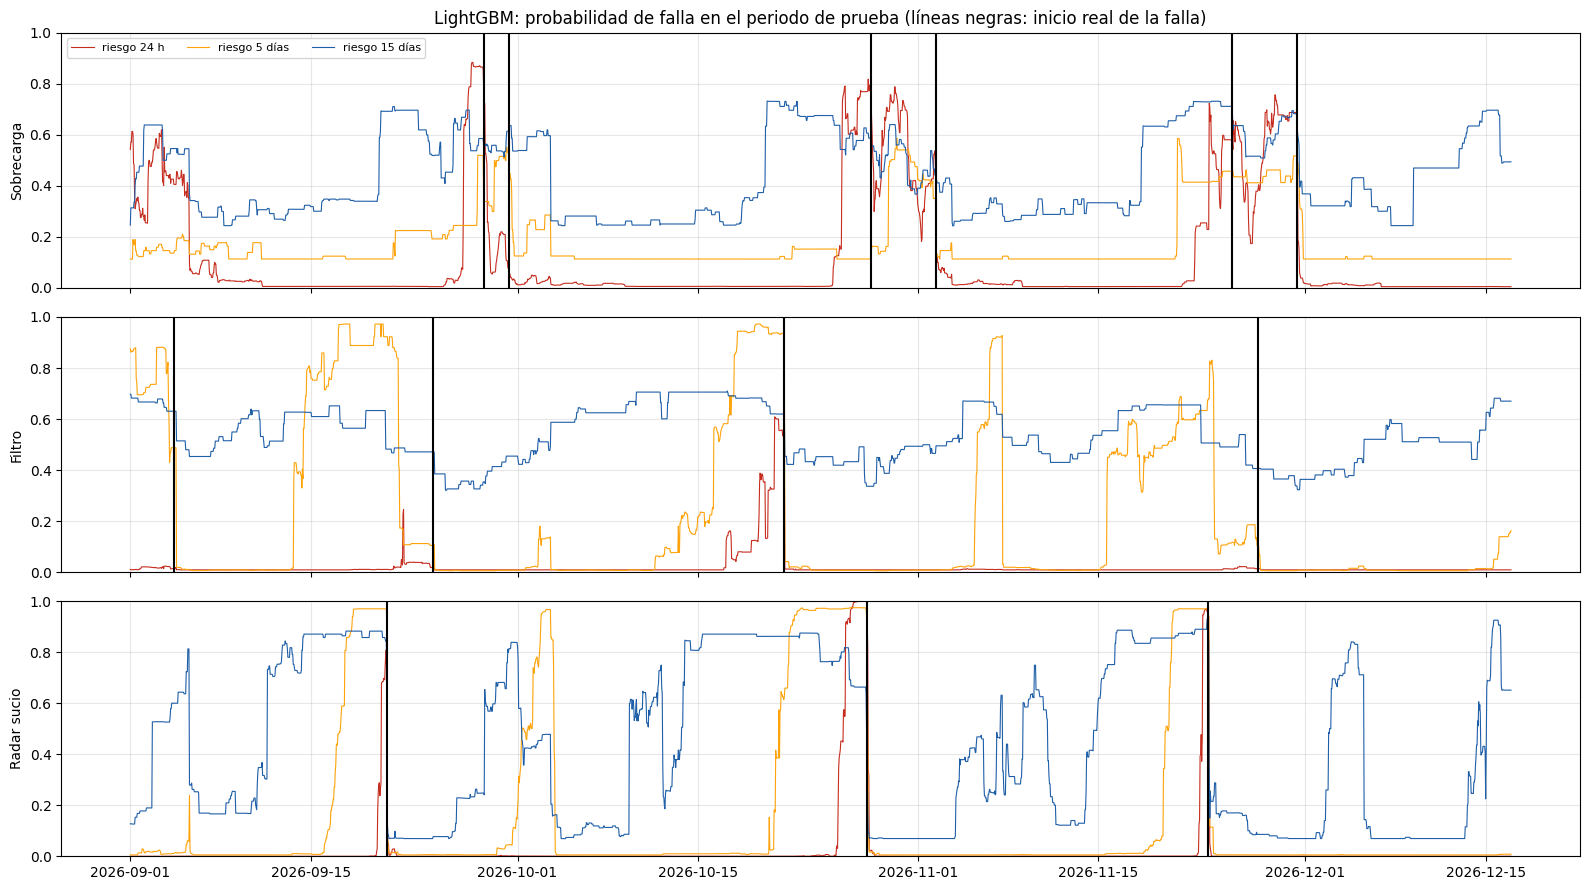

In [19]:
MEJOR = resumen_fam["PR_AUC_val"].idxmax()
print("Mejor familia según validación:", MEJOR)

fig, axes = plt.subplots(len(FALLAS_ML), 1, figsize=(16, 9), sharex=True)
for ax, f in zip(axes, FALLAS_ML):
    for hz, color in zip(HORIZONTES, ["#C62D1F", "#FEA30B", "#1F5FA8"]):
        ax.plot(tiempos_te, prob_test[MEJOR, f, hz], lw=0.8, color=color, label=f"riesgo {hz}")
    for s in EVENTOS[f]:
        if tiempos_te.min() <= s <= tiempos_te.max():
            ax.axvline(s, color="black", lw=1.5)
    ax.set_ylabel(CORTO[f]); ax.set_ylim(0, 1); ax.grid(alpha=0.3)
axes[0].legend(ncol=3, fontsize=8, loc="upper left")
axes[0].set_title(f"{MEJOR}: probabilidad de falla en el periodo de prueba (líneas negras: inicio real de la falla)")
plt.tight_layout(); plt.show()

## 5.3 ¿Qué variables usa el modelo?

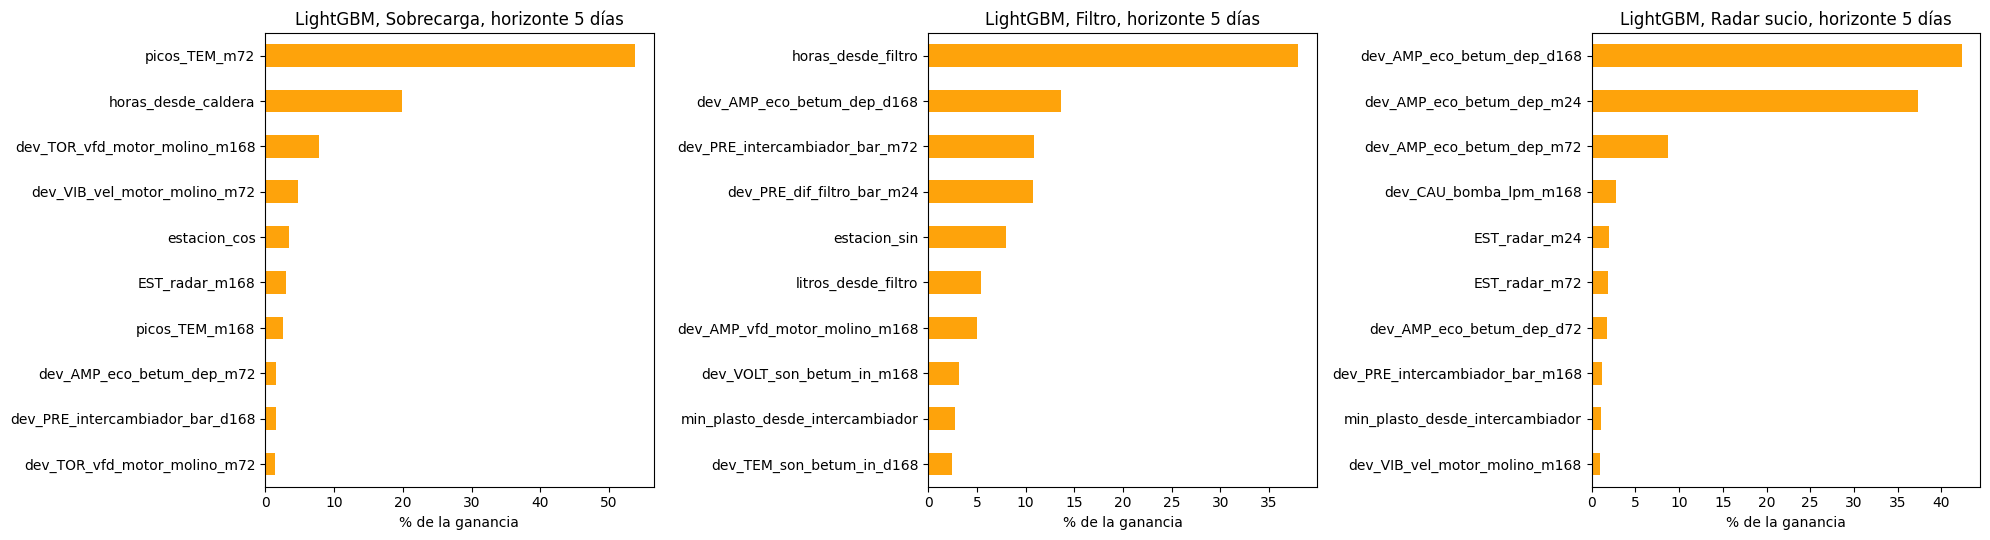

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5.5))
for ax, f in zip(axes, FALLAS_ML):
    m = FINALES["LightGBM"][f, "5 días"]
    imp = pd.Series(m.booster_.feature_importance("gain"), index=FEATURES_TAB).sort_values().tail(10)
    (imp / imp.sum() * 100).plot(kind="barh", ax=ax, color="#FEA30B")
    ax.set_title(f"LightGBM, {CORTO[f]}, horizonte 5 días"); ax.set_xlabel("% de la ganancia")
plt.tight_layout(); plt.show()

# 6. Pronóstico por tendencia para fallas raras

Para las cuatro fallas con 2 a 5 eventos al año no hay ejemplos suficientes para entrenar. Se usa un método que **no necesita ejemplos de falla**, solo conocer el límite físico:

1. Se calcula un **indicador diario** de la degradación.
2. Cada día se ajusta una recta a los últimos 7 días del indicador.
3. Se proyecta en cuántos días cruzará el límite de falla, y se emite la alerta si eso ocurre dentro del horizonte.

| Falla | Indicador diario | Límite |
|---|---|---|
| Cortocircuito del caudalímetro | Corriente de fuga del lazo (desviación media) | +1,2 mA |
| Pt100 del betún | Voltaje de alimentación (desviación mediana) | −1,3 V |
| Intercambiador | Presión en producción plastomérica (desviación media) | +1,0 bar |
| Rodamientos | Vibración en producción (desviación media) | +2,5 mm/s |

Se aplica también al **filtro** (presión diferencial, límite +0,7 bar sobre lo normal) para compararlo con el machine learning. Como el método no se entrena, se evalúa sobre todo el año.

In [21]:
dia = df["timestamp"].dt.floor("D")
INDICADORES = {
    "Cortocircuito_Transmisor_Caudal_Sol": (res["dev_AMP_cau_solucion_in"].groupby(dia).mean(), 1.2, +1),
    "Falla_Electrica_PT100_Betun": (res["dev_VOLT_son_betum_in"].groupby(dia).median(), -1.3, -1),
    "Ensuciamiento_Intercambiador": (res["dev_PRE_intercambiador_bar"].groupby(dia).mean(), 1.0, +1),
    "Desgaste_Rodamientos_Molino": (res["dev_VIB_vel_motor_molino"].groupby(dia).mean(), 2.5, +1),
    "Filtro_Obstruido": (res["dev_PRE_dif_filtro_bar"].groupby(dia).mean(), 0.7, +1),
}

def dias_hasta_limite(serie, limite, signo, ventana=7):
    s = serie.dropna()
    salida = pd.Series(np.inf, index=serie.index)
    for i in range(len(s)):
        tramo = s.iloc[max(0, i - ventana + 1): i + 1]
        if len(tramo) < 3:
            continue
        x = (tramo.index - tramo.index[0]).days.values.astype(float)
        pend, inter = np.polyfit(x, tramo.values, 1)
        actual = pend * x[-1] + inter
        if signo * (actual - limite) >= 0:
            salida[s.index[i]] = 0.0
        elif signo * pend > 1e-6:
            salida[s.index[i]] = (limite - actual) / pend
    return salida.ffill()

filas, PRONOSTICOS = [], {}
for f, (serie, limite, signo) in INDICADORES.items():
    d = dias_hasta_limite(serie, limite, signo)
    PRONOSTICOS[f] = d
    tiempos = (d.index + pd.Timedelta(days=1)).values                   # alerta emitida al cerrar el día
    activo = (df[TARGET] == f).groupby(dia).any().reindex(d.index, fill_value=False).values
    for hz, h in HORIZONTES.items():
        alerta = (d.values <= h / 24).astype(float)
        ev = evaluar_eventos(alerta, 0.5, tiempos, EVENTOS[f], h, activo)
        filas.append({"falla": CORTO[f], "horizonte": hz, **ev})
TENDENCIA = pd.DataFrame(filas).set_index(["falla", "horizonte"])
TENDENCIA.round(1)

eventos  anticipados_%  anticipacion_media_h  anticipados_3dias_%  falsas_alertas_mes
falla          horizonte                                                                                       
Cortocircuito  24 h             5           80.0                  11.6                  0.0                 0.6
               5 días           5          100.0                  89.2                100.0                 0.6
               15 días          5          100.0                 214.0                100.0                 0.9
Pt100          24 h             4            0.0                   NaN                  0.0                 0.2
               5 días           4          100.0                  64.0                 25.0                 0.2
               15 días          4          100.0                 220.0                100.0                 0.4
Intercambiador 24 h             5            0.0                   NaN                  0.0                 0.0
               5 días           5            0.0                   NaN                  0.0                 0.0
               15 días          5            0.0                   NaN                  0.0                 0.0
Rodamientos    24 h             2          100.0                  12.3                  0.0                 0.5
               5 días           2          100.0                  84.3                 50.0                 0.6
               15 días          2          100.0                 348.3                100.0                 0.9
Filtro         24 h            12            0.0                   NaN                  0.0                 0.0
               5 días          12           41.7                  50.4                  8.3                 0.0
               15 días         12          100.0                 161.9                 91.7                 0.6

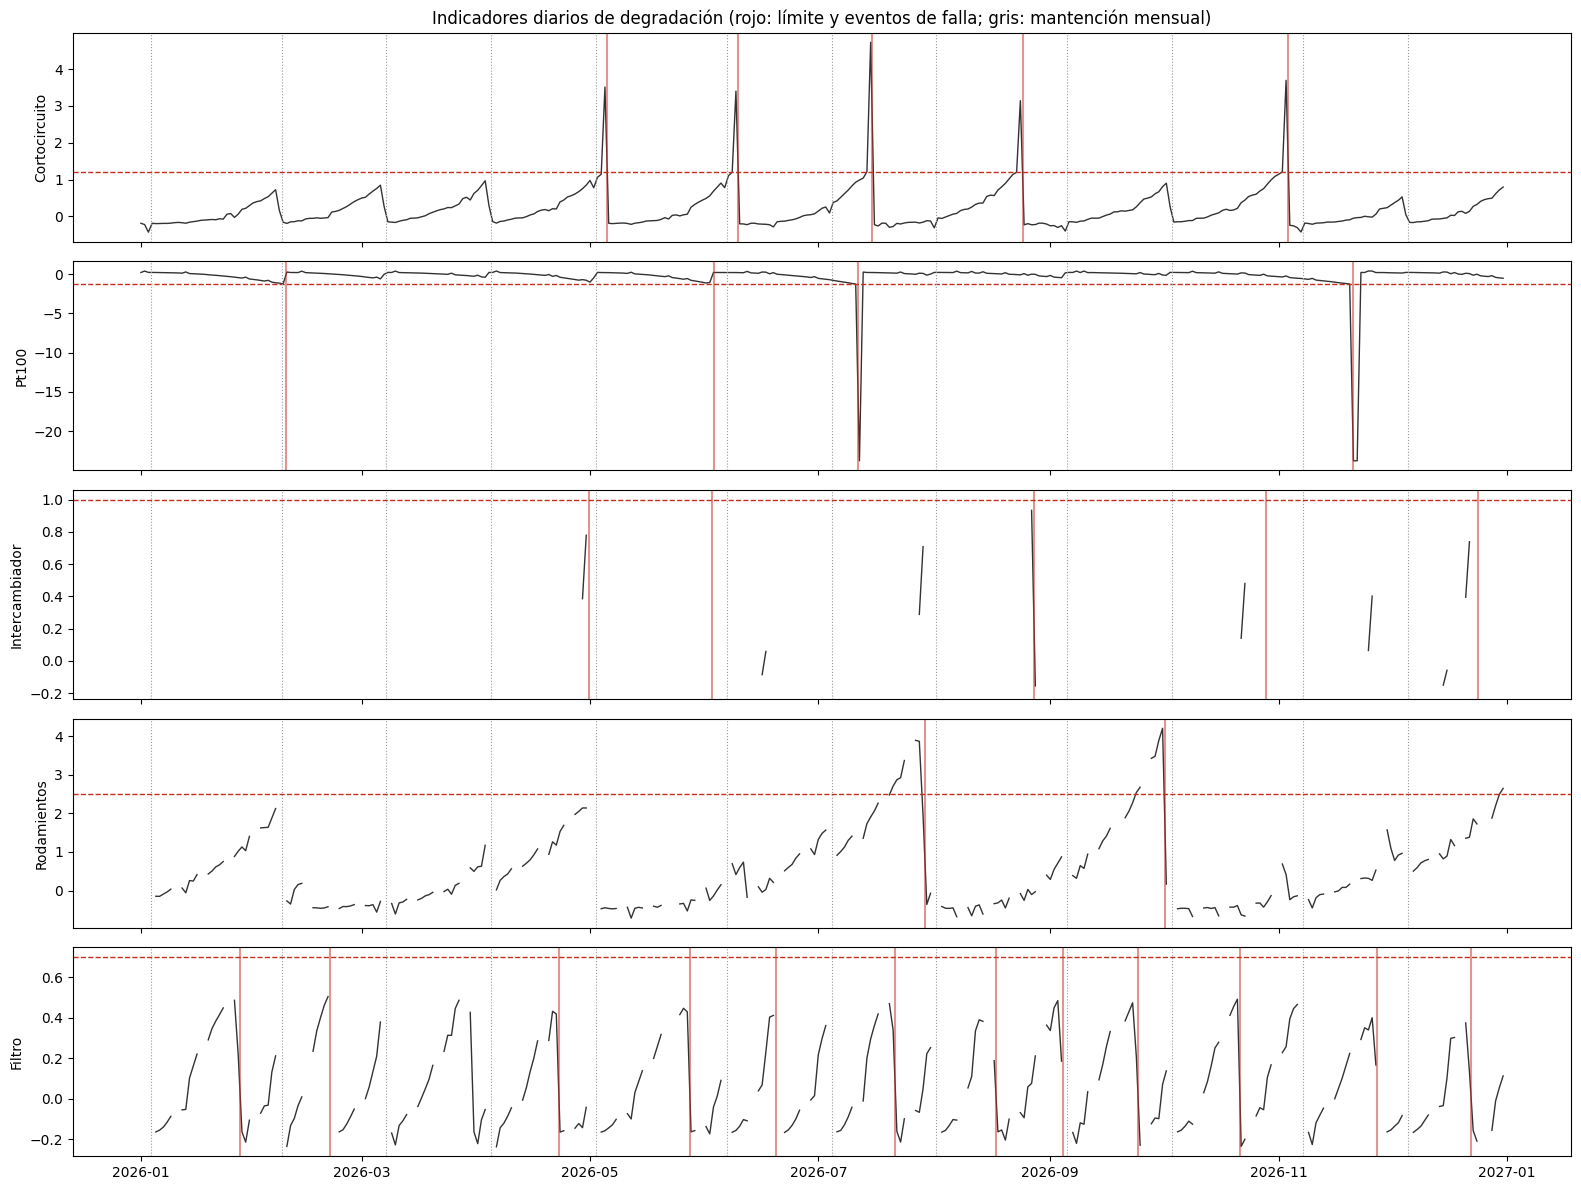

In [22]:
fig, axes = plt.subplots(len(INDICADORES), 1, figsize=(16, 12), sharex=True)
for ax, (f, (serie, limite, signo)) in zip(axes, INDICADORES.items()):
    ax.plot(serie.index, serie.values, color="#333", lw=1)
    ax.axhline(limite, color="#C62D1F", ls="--", lw=1)
    for s in EVENTOS[f]:
        ax.axvline(s, color="#C62D1F", alpha=0.5)
    for m in bit.loc[bit["tipo"] != "Correctiva", "timestamp"]:
        ax.axvline(m, color="#999", ls=":", lw=0.8)
    ax.set_ylabel(CORTO[f])
axes[0].set_title("Indicadores diarios de degradación (rojo: límite y eventos de falla; gris: mantención mensual)")
plt.tight_layout(); plt.show()

## 6.1 Comparación en el filtro: machine learning vs tendencia

In [23]:
comp_filtro = pd.concat({
    MEJOR: RESULTADOS[(RESULTADOS["modelo"] == MEJOR) & (RESULTADOS["falla"] == "Filtro")].set_index("horizonte")[["eventos", "anticipados_%", "anticipacion_media_h", "falsas_alertas_mes"]],
    "Tendencia (año completo)": TENDENCIA.loc["Filtro"][["eventos", "anticipados_%", "anticipacion_media_h", "falsas_alertas_mes"]],
}, axis=1)
comp_filtro.round(1)

LightGBM                                                       Tendencia (año completo)                                                      
           eventos anticipados_% anticipacion_media_h falsas_alertas_mes                  eventos anticipados_% anticipacion_media_h falsas_alertas_mes
horizonte                                                                                                                                              
24 h             4          25.0                 23.8                1.1                       12           0.0                  NaN                0.0
5 días           3         100.0                119.4                2.0                       12          41.7                 50.4                0.0
15 días          4         100.0                359.5                2.5                       12         100.0                161.9                0.6

# 7. Del pronóstico a la acción: semáforo de riesgo

Así se vería el resultado en el dashboard: para cada equipo y horizonte, el riesgo actual y la acción sugerida. El ejemplo usa una hora del periodo de prueba.

In [24]:
ACCIONES = {"Sobrecarga_Motor_Por_Asfalto_Frio": "Revisar caldera y calefacción del estanque TK-101",
            "Filtro_Obstruido": "Programar limpieza del filtro F-101",
            "Advertencia_Radar_Sucio_Betun": "Programar limpieza de la antena del radar de TK-101",
            "Cortocircuito_Transmisor_Caudal_Sol": "Secar y sellar el transmisor FT-201",
            "Falla_Electrica_PT100_Betun": "Reapretar borneras y revisar la alimentación de la Pt100",
            "Ensuciamiento_Intercambiador": "Programar limpieza química del intercambiador E-301",
            "Desgaste_Rodamientos_Molino": "Programar cambio de rodamientos del molino"}

def semaforo(i_hora):
    t = t_pred[i_hora]
    filas = []
    for f in FALLAS_ML:
        fila = {"falla": CORTO[f], "método": MEJOR}
        for hz in HORIZONTES:
            p = prob_test[MEJOR, f, hz][np.where(np.where(en_te)[0] == i_hora)[0][0]]
            fila[hz] = "ALTO" if p >= UMBRALES[MEJOR, f, hz] else "bajo"
        filas.append(fila)
    for f in FALLAS_TENDENCIA:
        d = PRONOSTICOS[f].asof(t.floor("D") - pd.Timedelta(days=1))
        filas.append({"falla": CORTO[f], "método": "Tendencia",
                      **{hz: "ALTO" if d <= h / 24 else "bajo" for hz, h in HORIZONTES.items()}})
    tabla = pd.DataFrame(filas).set_index("falla")
    tabla["acción sugerida"] = [ACCIONES[f] if (tabla.loc[CORTO[f], list(HORIZONTES)] == "ALTO").any() else "" for f in FALLAS_ML + FALLAS_TENDENCIA]
    return t, tabla

# una hora 3 días antes de un evento de filtro en prueba
ev_filtro = [s for s in EVENTOS["Filtro_Obstruido"] if s > np.datetime64(FIN_VALIDACION)][0]
i_ej = int(np.searchsorted(t_pred.values, ev_filtro - np.timedelta64(72, "h")))
t_ej, tabla_ej = semaforo(i_ej)
print(f"Riesgo emitido el {t_ej:%d-%m-%Y %H:%M} (la obstrucción real del filtro ocurrió el {pd.Timestamp(ev_filtro):%d-%m-%Y %H:%M})")
tabla_ej.style.map(lambda v: "background-color: #C62D1F; color: white; font-weight: 600" if v == "ALTO" else "", subset=list(HORIZONTES))

Riesgo emitido el 01-09-2026 10:00 (la obstrucción real del filtro ocurrió el 04-09-2026 09:41)


,método,24 h,5 días,15 días,acción sugerida
falla,,,,,
Sobrecarga,LightGBM,ALTO,bajo,bajo,Revisar caldera y calefacción del estanque TK-101
Filtro,LightGBM,bajo,ALTO,ALTO,Programar limpieza del filtro F-101
Radar sucio,LightGBM,bajo,bajo,ALTO,Programar limpieza de la antena del radar de TK-101
Cortocircuito,Tendencia,bajo,bajo,bajo,
Pt100,Tendencia,bajo,bajo,bajo,
Intercambiador,Tendencia,bajo,bajo,bajo,
Rodamientos,Tendencia,bajo,bajo,bajo,


# 8. Conclusiones

*(Valores de la ejecución de referencia; pueden variar levemente entre corridas, sobre todo en la LSTM.)*

## 8.1 Mejor modelo: LightGBM con variables de tendencia

| Modelo | PR-AUC validación | PR-AUC prueba | Eventos anticipados | Anticipación media | Falsas alertas por mes |
|---|---|---|---|---|---|
| **LightGBM** | **0,74** | 0,74 | 90 % | 148 h | 1,6 |
| Random Forest | 0,65 | 0,75 | 94 % | 160 h | 2,0 |
| LSTM | 0,61 | 0,63 | 68 % | 158 h | 1,2 |

*(Promedio de las 9 combinaciones falla × horizonte.)*

LightGBM fue el mejor en validación, que es el criterio de selección, y se exporta. Random Forest rindió parecido en prueba, con algo más de falsas alertas. La LSTM quedó atrás: con 12 a 19 eventos por falla en el año, una red recurrente no alcanza a aprender patrones de anticipación confiables, mientras que los árboles aprovechan las tendencias ya calculadas.

## 8.2 Resultados por horizonte (LightGBM, periodo de prueba)

| Falla | 24 horas | 5 días | 15 días |
|---|---|---|---|
| Sobrecarga | 6 de 6 eventos | 5 de 6, con ~105 h de anticipación | 6 de 6 |
| Filtro | 1 de 4 | 3 de 3, con ~119 h de anticipación | 4 de 4 |
| Radar sucio | 3 de 3 | 3 de 3, con ~104 h de anticipación | 4 de 4 |

* **5 días** es el horizonte más útil: anticipa casi todas las fallas con **4 a 5 días de margen**, justo el rango de 3–5 días buscado, tiempo suficiente para programar la intervención dentro del turno de lunes a viernes.
* **24 horas** funciona bien para sobrecarga y radar, pero no para el filtro: su obstrucción depende de cuánto se produzca al día siguiente, algo que el modelo no conoce de antemano.
* **15 días** anticipa todo, pero hay que interpretarlo con cuidado: como la mantención mensual reinicia el desgaste, cerca de la mitad de las horas tienen una falla en los 15 días siguientes. Sirve para decidir **qué tareas agregar a la próxima mantención mensual**, no como alarma.

Las variables más importantes son las de **desgaste acumulado desde la última intervención** (litros filtrados, horas desde la limpieza del radar o la mantención de la caldera) y las **tendencias de 3 a 7 días** de los sensores. Es decir, el modelo aprendió la física de la degradación, no atajos.

## 8.3 Fallas raras: pronóstico por tendencia

Sin entrenar ningún modelo, solo proyectando la tendencia de 7 días hacia el límite físico:

* **Cortocircuito del caudalímetro, Pt100 y rodamientos:** se anticipan el 100 % de los eventos a 5 y 15 días, con menos de una falsa alerta por mes.
* **Intercambiador:** el método no anticipó ningún evento. Su presión solo se mide los días de producción plastomérica (1 de cada 4) y el ensuciamiento avanza a saltos, por lo que la recta de 7 días no alcanza a captarlo. Para esta falla conviene una regla por uso: alertar cuando los minutos de producción plastomérica desde la última limpieza superen un umbral.
* **En el filtro**, LightGBM supera claramente a la tendencia a 5 días (100 % contra 42 % de eventos anticipados), lo que confirma el valor del machine learning cuando hay eventos suficientes.

## 8.4 De mantenimiento reactivo a predictivo

Con el semáforo de riesgo, la planta pasa de reparar cuando la máquina falla a intervenir antes:

| Hoy (reactivo) | Con el modelo (predictivo) |
|---|---|
| La falla detiene la producción | Se recibe una alerta 4 a 5 días antes |
| Reparación urgente, a veces fuera de turno | Intervención programada en horario hábil |
| Mantención mensual con tareas fijas | Mantención mensual priorizada según el riesgo a 15 días |
| Repuestos comprados con urgencia | Repuestos pedidos con anticipación |

## 8.5 Limitaciones y próximos pasos

* El periodo de prueba tiene entre 3 y 6 eventos por falla: los porcentajes cambian mucho con un solo evento. Hay que **validar con datos reales** de la planta a medida que se acumulen.
* El dataset es simulado; los mecanismos de degradación son razonables, pero las velocidades reales deben calibrarse con la bitácora real.
* Registrar en la bitácora **todas** las intervenciones, incluidas las limpiezas menores, porque el desgaste acumulado es la variable más importante del modelo.
* **Integrar el semáforo en el dashboard** y reentrenar cada 3 meses con los nuevos eventos y las etiquetas del operador.


# 9. Descarga del modelo predictivo

Se empaqueta todo lo necesario para emitir el semáforo de riesgo fuera de Colab:

* Los modelos de la mejor familia para las tres fallas frecuentes y los tres horizontes.
* Los **umbrales de alerta** elegidos en validación.
* Las **referencias de operación normal** y la lista de variables, para construir las variables igual que aquí.
* La configuración del **pronóstico por tendencia** (indicadores y límites) para las fallas raras.

Si la mejor familia es la LSTM, las redes se guardan como archivos `.keras` dentro del mismo `.zip`.

In [25]:
paquete = {
    "familia": MEJOR, "fallas_ml": FALLAS_ML, "fallas_tendencia": FALLAS_TENDENCIA, "horizontes": HORIZONTES,
    "umbrales": {(f, hz): UMBRALES[MEJOR, f, hz] for f in FALLAS_ML for hz in HORIZONTES},
    "features_tabulares": FEATURES_TAB, "columnas_secuencia": COLS_SEQ, "largo_secuencia": SEQ,
    "referencias_normal": REFERENCIAS, "sensores": SENSORES, "solo_produccion": SOLO_PRODUCCION,
    "intervenciones": INTERVENCIONES, "acciones": ACCIONES,
    "tendencia": {f: {"limite": lim, "signo": sg} for f, (_, lim, sg) in INDICADORES.items()},
    "versiones": {"sklearn": sklearn.__version__, "lightgbm": lgb.__version__, "tensorflow": tf.__version__},
}
archivos = ["modelo_predictivo.joblib"]
if MEJOR == "LightGBM":
    paquete["modelos"] = FINALES["LightGBM"]
elif MEJOR == "Random Forest":
    paquete["modelos"] = FINALES["Random Forest"]
else:
    paquete["escalador_secuencia"] = sc_seq
    paquete["modelos"] = {}
    for i, hz in enumerate(HORIZONTES):
        nombre = f"lstm_{i}.keras"
        FINALES["LSTM"][hz].save(nombre); archivos.append(nombre)
        paquete["modelos"][hz] = nombre
joblib.dump(paquete, "modelo_predictivo.joblib")

ZIP = "modelo_predictivo_molino_QLA.zip"
with zipfile.ZipFile(ZIP, "w") as z:
    for a in archivos:
        z.write(a)
print(f"Exportado: {MEJOR} -> {ZIP} ({', '.join(archivos)})")
try:
    from google.colab import files
    files.download(ZIP)
except ImportError:
    print("No se está ejecutando en Colab: el .zip quedó en la carpeta actual.")

Exportado: LightGBM -> modelo_predictivo_molino_QLA.zip (modelo_predictivo.joblib)
No se está ejecutando en Colab: el .zip quedó en la carpeta actual.


## 9.1 Cómo usar el modelo descargado

Para usarlo con datos nuevos, se deben construir las variables con las celdas de la sección 3 (las mismas funciones, aplicadas al dataset nuevo y a la bitácora actualizada) y luego llamar al modelo. Esta celda muestra la carga y la predicción para la última hora disponible del periodo de prueba.

In [26]:
pq = joblib.load("modelo_predictivo.joblib")
i_ult = np.where(en_te)[0][-1]
filas = []
for f in pq["fallas_ml"]:
    fila = {"falla": CORTO[f]}
    for hz in pq["horizontes"]:
        if pq["familia"] == "LightGBM":
            p = pq["modelos"][f, hz].predict_proba(TAB.iloc[[i_ult]][pq["features_tabulares"]].values)[0, 1]
        elif pq["familia"] == "Random Forest":
            p = prob_multi(pq["modelos"][hz], TAB.iloc[[i_ult]][pq["features_tabulares"]].values)[0, pq["fallas_ml"].index(f)]
        else:
            p = keras.models.load_model(pq["modelos"][hz]).predict(SEQS[[i_ult - (SEQ - 1)]], verbose=0)[0, pq["fallas_ml"].index(f)]
        fila[f"prob. {hz}"] = round(float(p), 3)
        fila[f"alerta {hz}"] = "ALTO" if p >= pq["umbrales"][f, hz] else "bajo"
    filas.append(fila)
print(f"Predicción para {t_pred[i_ult]:%d-%m-%Y %H:%M}")
pd.DataFrame(filas).set_index("falla")

Predicción para 16-12-2026 23:00


,prob. 24 h,alerta 24 h,prob. 5 días,alerta 5 días,prob. 15 días,alerta 15 días
falla,,,,,,
Sobrecarga,0.005,bajo,0.114,bajo,0.494,ALTO
Filtro,0.009,bajo,0.162,ALTO,0.670,ALTO
Radar sucio,0.000,bajo,0.008,bajo,0.651,ALTO
